# A/B Test Analysis: Credit Reminder Feature
## Онбординг → конверсія в першу оплату

**Аналіз виконав:** Мельник Максим

**Гіпотеза:** Закріплене нагадування в чаті (з'являється при ≤5 кредитах) збільшує конверсію в першу оплату.

**Метрика:** Conversion Rate = кількість юзерів з першою оплатою / загальна кількість юзерів у групі


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
from scipy.stats import chi2_contingency, norm, mannwhitneyu
from math import ceil
# Визначаємо межі тесту — використовується скрізь в аналізі
TEST_START = pd.Timestamp('2023-03-14', tz='UTC')
TEST_END   = pd.Timestamp('2023-04-19', tz='UTC')  # не включно, щоб захопити весь день 2023-04-18

HIST_START = pd.Timestamp('2023-03-01', tz='UTC')
HIST_END   = pd.Timestamp('2023-03-10', tz='UTC')  # не включно

In [60]:
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

# завантаження
hist = pd.read_csv('ab_test_task_historical_data.csv')
ab   = pd.read_csv('ab_test_task_data.csv')

# парсинг дат
date_cols_hist = ['date_reg', 'date_first_payment', 'date_spent_15_credits']
date_cols_ab   = date_cols_hist + ['date_reminder']

for col in date_cols_hist:
    hist[col] = pd.to_datetime(hist[col], utc=True, errors='coerce')

for col in date_cols_ab:
    ab[col] = pd.to_datetime(ab[col], utc=True, errors='coerce')

# перевірка
print(f"Historical: {len(hist):,} рядків, {hist['date_reg'].min().date()} → {hist['date_reg'].max().date()}")
print(f"AB test:    {len(ab):,} рядків, {ab['date_reg'].min().date()} → {ab['date_reg'].max().date()}")
print()
print("Пропуски historical:")
print(hist.isnull().sum())
print()
print("Пропуски AB test:")
print(ab.isnull().sum())

Historical: 59,758 рядків, 2023-03-01 → 2023-03-09
AB test:    125,217 рядків, 2023-03-14 → 2023-04-18

Пропуски historical:
id_user                      0
date_reg                     0
date_first_payment       56501
date_spent_15_credits    37490
dtype: int64

Пропуски AB test:
id_user                       0
date_reg                      0
date_first_payment       117980
date_spent_15_credits     73664
date_reminder            110009
match                         0
dtype: int64


In [82]:
print("=" * 65)
print(f"{'ПЕРЕВІРКА ЯКОСТІ ДАНИХ':^65}")
print("=" * 65)

# --- Historical ---
print("\n HISTORICAL:")
print(f"  Повні дублікати рядків:        {hist.duplicated().sum():,}")
print(f"  Дублікати по id_user:          {hist.duplicated(subset='id_user').sum():,}")

out_hist = hist[(hist['date_reg'] < HIST_START) | (hist['date_reg'] >= HIST_END)]
print(f"  Реєстрації поза періодом:      {len(out_hist):,}")

pay_before_reg_hist = hist[
    hist['date_first_payment'].notna() &
    (hist['date_first_payment'] < hist['date_reg'])
].shape[0]
print(f"  Оплата раніше реєстрації:      {pay_before_reg_hist:,}")

spent_before_reg_hist = hist[
    hist['date_spent_15_credits'].notna() &
    (hist['date_spent_15_credits'] < hist['date_reg'])
].shape[0]
print(f"  Витрата 15 раніше реєстрації:  {spent_before_reg_hist:,}")

# --- AB test ---
print("\nAB TEST:")
print(f"  Повні дублікати рядків:        {ab.duplicated().sum():,}")
print(f"  Дублікати по id_user:          {ab.duplicated(subset='id_user').sum():,}")

both_groups = ab.groupby('id_user')['match'].nunique()
print(f"  Юзери в обох групах:           {(both_groups > 1).sum():,}")

out_ab = ab[(ab['date_reg'] < TEST_START) | (ab['date_reg'] >= TEST_END)]
print(f"  Реєстрації поза періодом:      {len(out_ab):,}")

pay_before_reg_ab = ab[
    ab['date_first_payment'].notna() &
    (ab['date_first_payment'] < ab['date_reg'])
].shape[0]
print(f"  Оплата раніше реєстрації:      {pay_before_reg_ab:,}")

spent_before_reg_ab = ab[
    ab['date_spent_15_credits'].notna() &
    (ab['date_spent_15_credits'] < ab['date_reg'])
].shape[0]
print(f"  Витрата 15 раніше реєстрації:  {spent_before_reg_ab:,}")

print("\n" + "=" * 65)

                     ПЕРЕВІРКА ЯКОСТІ ДАНИХ                      

 HISTORICAL:
  Повні дублікати рядків:        0
  Дублікати по id_user:          0
  Реєстрації поза періодом:      0
  Оплата раніше реєстрації:      0
  Витрата 15 раніше реєстрації:  0

AB TEST:
  Повні дублікати рядків:        0
  Дублікати по id_user:          0
  Юзери в обох групах:           0
  Реєстрації поза періодом:      0
  Оплата раніше реєстрації:      0
  Витрата 15 раніше реєстрації:  0



## 2. EDA: Historical та AB test

Перед аналізом тесту знайомимось з даними — перевіряємо трафік, конверсію та базові розподіли.

Для розрахунку base CR і денного трафіку використовуємо тільки **eligible юзерів** — тих хто одночасно відповідає двом умовам:
1. **Витратив 15 кредитів до завершення тесту** (2023-04-18) — дійшов до тригера нагадування
2. **Не платив до моменту витрати 15 кредитів** — нагадування могло вплинути на рішення

Решта юзерів — ті хто не дійшов до тригера або заплатив самостійно раніше — не є цільовою аудиторією фічі і не включаються в базові розрахунки.

=== Historical ===
Юзерів (всього):           59,758
Eligible юзерів:           20,553 (34.39%)
Base CR (eligible):        12.6940%
Денний трафік (всього):    6,640
Денний трафік (eligible):  2,284


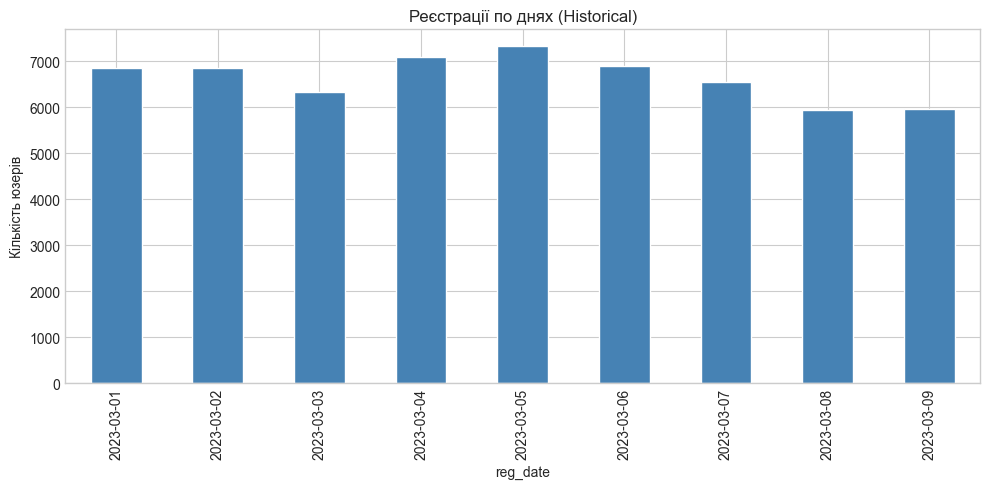


=== AB test ===
Юзерів (всього):           125,217
Днів:                      36
Медіана реєстрацій/день:   3,536
Середня реєстрацій/день:   3,575

Групи:
match
Test       62649
Control    62568
Name: count, dtype: int64


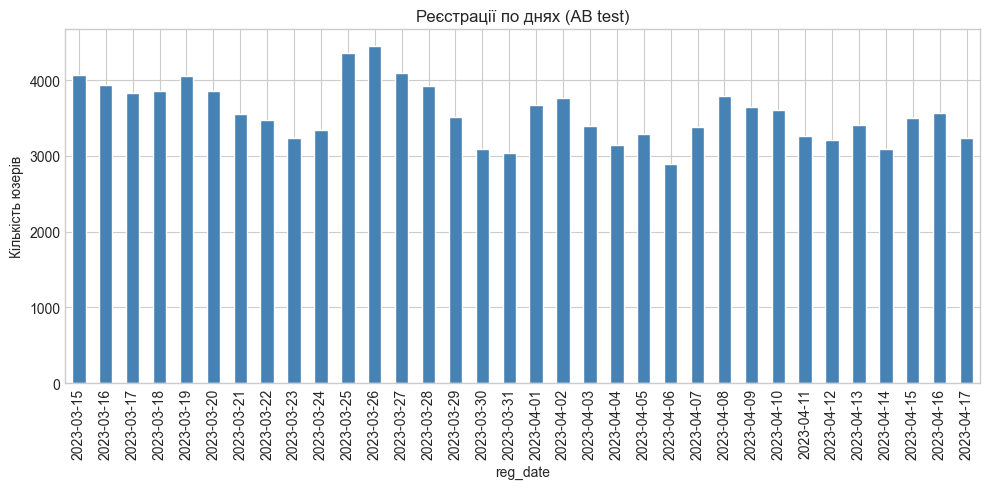

In [84]:
# --- Historical ---
hist['reg_date'] = hist['date_reg'].dt.date

hist_eligible = hist[
    hist['date_spent_15_credits'].notna() &
    (hist['date_spent_15_credits'] <= TEST_END) &
    (
        hist['date_first_payment'].isna() |
        (hist['date_first_payment'] >= hist['date_spent_15_credits'])
    )
]

eligible_share      = len(hist_eligible) / len(hist)
base_cr             = hist_eligible['date_first_payment'].notna().mean()
hist_daily_total    = hist.groupby('reg_date').size().mean()
hist_daily_eligible = hist_daily_total * eligible_share

daily_hist = hist.groupby('reg_date').size()

print("=== Historical ===")
print(f"Юзерів (всього):           {len(hist):,}")
print(f"Eligible юзерів:           {len(hist_eligible):,} ({eligible_share:.2%})")
print(f"Base CR (eligible):        {base_cr:.4%}")
print(f"Денний трафік (всього):    {hist_daily_total:,.0f}")
print(f"Денний трафік (eligible):  {hist_daily_eligible:,.0f}")

daily_hist.plot(kind='bar', figsize=(10, 5), color='steelblue',
                edgecolor='white', title='Реєстрації по днях (Historical)')
plt.ylabel('Кількість юзерів')
plt.tight_layout()
plt.show()

# --- AB test ---
ab['reg_date'] = ab['date_reg'].dt.date
daily_ab = ab.groupby('reg_date').size().iloc[1:-1]
ab_daily = daily_ab.mean()

print("\n=== AB test ===")
print(f"Юзерів (всього):           {len(ab):,}")
print(f"Днів:                      {ab['date_reg'].dt.date.nunique()}")
print(f"Медіана реєстрацій/день:   {daily_ab.median():,.0f}")
print(f"Середня реєстрацій/день:   {daily_ab.mean():,.0f}")
print()
print("Групи:")
print(ab['match'].value_counts().rename({0: 'Control', 1: 'Test'}))

daily_ab.plot(kind='bar', figsize=(10, 5), color='steelblue',
              edgecolor='white', title='Реєстрації по днях (AB test)')
plt.ylabel('Кількість юзерів')
plt.tight_layout()
plt.show()

## 3. Розрахунок необхідної тривалості тесту

Щоб зрозуміти чи вистачило часу для тесту, розраховуємо **мінімально необхідну кількість днів** для детектування ефекту різного розміру.

Використовуємо historical дані — але не по всіх юзерах, а лише по **eligible** сегменту. Eligible — це юзери які:
1. Витратили 15 кредитів **до завершення тесту** (2023-04-18)
2. Не платили до моменту витрати 15 кредитів

Саме вони є цільовою аудиторією фічі, тому base CR і денний трафік рахуємо по них.

**Параметри розрахунку:**
- α = 0.05 — ймовірність помилково побачити ефект якого немає
- Power = 80% — ймовірність знайти ефект якщо він є
- Split = 50/50
- MDE — мінімальний ефект який хочемо зафіксувати (наприклад 10% означає зміну CR з 12.67% до 13.94%)

Всього юзерів (hist):      59,758
Eligible юзерів:           20,553 (34.39%)
Base CR (eligible):        12.6940%
Денний трафік (всього):    6,640
Денний трафік (eligible):  2,284

   MDE |    n/group |    Total n |     Днів
------------------------------------------
   5% |     44,101 |     88,202 |       39
   6% |     30,752 |     61,504 |       27
   7% |     22,685 |     45,370 |       20
  10% |     11,250 |     22,500 |       10
  15% |      5,099 |     10,198 |        5
  20% |      2,922 |      5,844 |        3
  25% |      1,905 |      3,810 |        2
  30% |      1,346 |      2,692 |        2


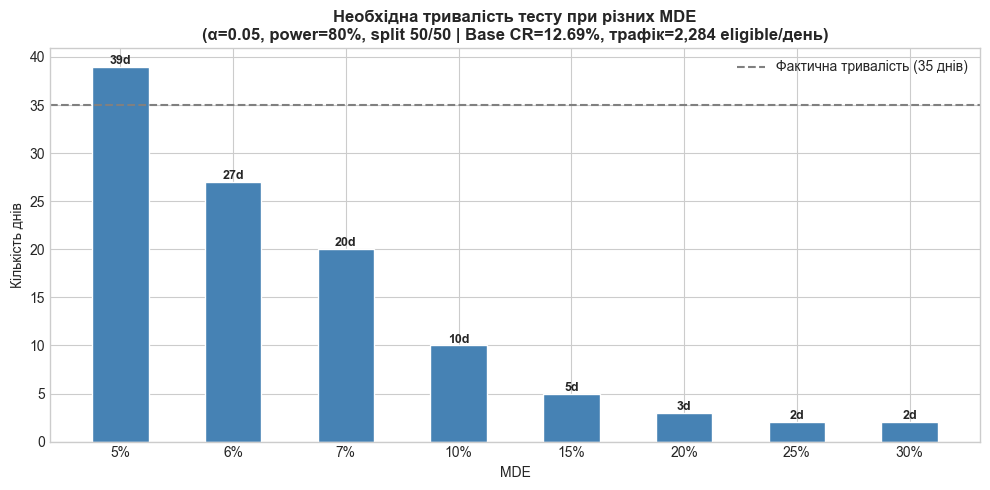

In [101]:
def get_sample_size(p_base, mde_relative, alpha=0.05, power=0.80):
    p_new   = p_base * (1 + mde_relative)
    z_alpha = norm.ppf(1 - alpha / 2)
    z_beta  = norm.ppf(power)
    n = (z_alpha + z_beta)**2 * (p_base*(1-p_base) + p_new*(1-p_new)) / (p_new - p_base)**2
    return ceil(n)

# base_cr, hist_daily_eligible — вже розраховані в секції 2
print(f"Всього юзерів (hist):      {len(hist):,}")
print(f"Eligible юзерів:           {len(hist_eligible):,} ({eligible_share:.2%})")
print(f"Base CR (eligible):        {base_cr:.4%}")
print(f"Денний трафік (всього):    {hist_daily_total:,.0f}")
print(f"Денний трафік (eligible):  {hist_daily_eligible:,.0f}")
print()
print(f"{'MDE':>6} | {'n/group':>10} | {'Total n':>10} | {'Днів':>8}")
print("-" * 42)
for mde in [0.05, 0.06, 0.07, 0.10, 0.15, 0.20, 0.25, 0.30]:
    n    = get_sample_size(base_cr, mde)
    days = ceil(n * 2 / hist_daily_eligible)
    print(f"{mde:>5.0%} | {n:>10,} | {n*2:>10,} | {days:>8}")

# --- Графік ---
mdes      = [0.05, 0.06, 0.07, 0.10, 0.15, 0.20, 0.25, 0.30]
days_list = [ceil(get_sample_size(base_cr, m) * 2 / hist_daily_eligible) for m in mdes]

x = np.arange(len(mdes))
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(x, days_list, width=0.5, color='steelblue', edgecolor='white')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{int(bar.get_height())}d', ha='center', fontsize=9, fontweight='bold')

ax.axhline(35, color='gray', linestyle='--', linewidth=1.5,
           label='Фактична тривалість (35 днів)')
ax.set_xticks(x)
ax.set_xticklabels([f'{m:.0%}' for m in mdes])
ax.set_xlabel('MDE')
ax.set_ylabel('Кількість днів')
ax.set_title(
    f'Необхідна тривалість тесту при різних MDE\n'
    f'(α=0.05, power=80%, split 50/50 | '
    f'Base CR={base_cr:.2%}, трафік={hist_daily_eligible:,.0f} eligible/день)',
    fontweight='bold'
)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Огляд груп та сегментація

Перед тим як переходити до статистичного тесту, важливо зрозуміти **хто саме міг побачити нагадування** — адже не всі юзери є релевантними для оцінки ефекту фічі.

Нагадування з'являється лише тоді, коли у юзера залишається ≤5 кредитів — тобто після того як він витратив 15 з 20 бонусних кредитів. Але навіть серед тих хто витратив 15 кредитів є юзери на яких фіча **не могла вплинути**:

- **Не витратили 15 кредитів взагалі** — не дійшли до тригера, нагадування не з'явилось би навіть у тестовій групі
- **Заплатили ДО витрати 15 кредитів** — вже сконвертувались самостійно до того як нагадування могло спрацювати
- **Витратили 15 кредитів після завершення тесту (після 2023-04-18)** — тест вже закінчився, нагадування технічно не могло з'явитись

Включення цих юзерів у розрахунок CR **розмиває реальний ефект** фічі — вони конвертуються (або ні) незалежно від нагадування, і лише шумлять у даних.

Тому виділяємо окремий сегмент — **Eligible** — юзери які одночасно відповідають трьом умовам:
1. Витратили 15 кредитів (дійшли до тригера нагадування)
2. Зробили це до завершення тесту (2023-04-18)
3. Не платили до моменту витрати 15 кредитів (нагадування могло вплинути на рішення)

Саме по цьому сегменту будемо рахувати основний CR і проводити статистичний тест.

In [87]:
ctrl = ab[ab['match'] == 0].copy()
test = ab[ab['match'] == 1].copy()

def segment(df):
    no_15 = df[df['date_spent_15_credits'].isna()]

    paid_before = df[
        df['date_spent_15_credits'].notna() &
        df['date_first_payment'].notna() &
        (df['date_first_payment'] < df['date_spent_15_credits'])
    ]

    after_test = df[
        df['date_spent_15_credits'].notna() &
        (df['date_spent_15_credits'] > TEST_END) &
        ~(
            df['date_first_payment'].notna() &
            (df['date_first_payment'] < df['date_spent_15_credits'])
        )
    ]

    eligible = df[
        df['date_spent_15_credits'].notna() &
        (df['date_spent_15_credits'] <= TEST_END) &
        (
            df['date_first_payment'].isna() |
            (df['date_first_payment'] >= df['date_spent_15_credits'])
        )
    ]

    return no_15, paid_before, after_test, eligible

ctrl_no15, ctrl_paid_before, ctrl_after, ctrl_elig = segment(ctrl)
test_no15, test_paid_before, test_after, test_elig = segment(test)

print("=" * 65)
print(f"{'ОГЛЯД ГРУП':^65}")
print("=" * 65)
print(f"{'':35} {'Control':>12} {'Test':>12}")
print("-" * 65)
print(f"{'Всього юзерів':35} {len(ctrl):>12,} {len(test):>12,}")
print(f"{'CR (всі юзери)':35} {ctrl['date_first_payment'].notna().mean():>12.2%} {test['date_first_payment'].notna().mean():>12.2%}")
print()
print(f"{'🔵 Не витратили 15 кредитів':35} {len(ctrl_no15):>12,} {len(test_no15):>12,}")
print(f"{'   % від групи':35} {len(ctrl_no15)/len(ctrl):>12.2%} {len(test_no15)/len(test):>12.2%}")
print(f"{'   CR':35} {ctrl_no15['date_first_payment'].notna().mean():>12.2%} {test_no15['date_first_payment'].notna().mean():>12.2%}")
print()
print(f"{'🟡 Заплатили ДО витрати 15':35} {len(ctrl_paid_before):>12,} {len(test_paid_before):>12,}")
print(f"{'   % від групи':35} {len(ctrl_paid_before)/len(ctrl):>12.2%} {len(test_paid_before)/len(test):>12.2%}")
print()
print(f"{'🟠 Витратили 15 після кінця тесту':35} {len(ctrl_after):>12,} {len(test_after):>12,}")
print(f"{'   % від групи':35} {len(ctrl_after)/len(ctrl):>12.2%} {len(test_after)/len(test):>12.2%}")
print()
print(f"{'🟢 Eligible (дійшли до тригера)':35} {len(ctrl_elig):>12,} {len(test_elig):>12,}")
print(f"{'   % від групи':35} {len(ctrl_elig)/len(ctrl):>12.2%} {len(test_elig)/len(test):>12.2%}")
print(f"{'   CR':35} {ctrl_elig['date_first_payment'].notna().mean():>12.2%} {test_elig['date_first_payment'].notna().mean():>12.2%}")
print()
total_ctrl = len(ctrl_no15)+len(ctrl_paid_before)+len(ctrl_after)+len(ctrl_elig)
total_test = len(test_no15)+len(test_paid_before)+len(test_after)+len(test_elig)
print(f"{'Сума сегментів':35} {total_ctrl:>12,} {total_test:>12,}")
print("=" * 65)

                           ОГЛЯД ГРУП                            
                                         Control         Test
-----------------------------------------------------------------
Всього юзерів                             62,568       62,649
CR (всі юзери)                             5.60%        5.96%

🔵 Не витратили 15 кредитів                36,873       36,791
   % від групи                            58.93%       58.73%
   CR                                      0.12%        0.13%

🟡 Заплатили ДО витрати 15                    348          352
   % від групи                             0.56%        0.56%

🟠 Витратили 15 після кінця тесту           2,624        2,620
   % від групи                             4.19%        4.18%

🟢 Eligible (дійшли до тригера)            22,723       22,886
   % від групи                            36.32%       36.53%
   CR                                     12.40%       13.26%

Сума сегментів                            62,568       62

## 5. Фільтрація вибірки — залишаємо тільки Eligible юзерів

Огляд груп показав що лише частина юзерів реально могла потрапити під вплив фічі. Тому перед статистичним тестом **видаляємо з обох груп** юзерів які знаходяться поза зоною впливу нагадування:

- тих хто **не витратив 15 кредитів** — не дійшли до тригера
- тих хто **заплатив до витрати 15 кредитів** — сконвертувались незалежно від фічі
- тих хто **витратив 15 кредитів після завершення тесту** — нагадування вже не могло з'явитись

Видалення симетричне — прибираємо однакові категорії з обох груп, що не спотворює порівняння. Після фільтрації `ctrl_clean` і `test_clean` — це наша чиста вибірка для статистичного тесту.

In [67]:
ctrl_clean = ctrl_elig.copy()
test_clean = test_elig.copy()

print("=" * 55)
print(f"{'ВИБІРКА ПІСЛЯ ФІЛЬТРАЦІЇ':^55}")
print("=" * 55)
print(f"{'':30} {'Control':>10} {'Test':>10}")
print("-" * 55)
print(f"{'До фільтрації':30} {len(ctrl):>10,} {len(test):>10,}")
print(f"{'Видалено (не витратили 15)':30} {len(ctrl_no15):>10,} {len(test_no15):>10,}")
print(f"{'Видалено (платили до 15)':30} {len(ctrl_paid_before):>10,} {len(test_paid_before):>10,}")
print(f"{'Видалено (після кінця тесту)':30} {len(ctrl_after):>10,} {len(test_after):>10,}")
print(f"{'Залишилось (eligible)':30} {len(ctrl_clean):>10,} {len(test_clean):>10,}")
print(f"{'% від початкової вибірки':30} {len(ctrl_clean)/len(ctrl):>10.2%} {len(test_clean)/len(test):>10.2%}")
print(f"{'CR':30} {ctrl_clean['date_first_payment'].notna().mean():>10.2%} {test_clean['date_first_payment'].notna().mean():>10.2%}")
print("=" * 55)

               ВИБІРКА ПІСЛЯ ФІЛЬТРАЦІЇ                
                                  Control       Test
-------------------------------------------------------
До фільтрації                      62,479     62,649
Видалено (не витратили 15)         36,843     36,791
Видалено (платили до 15)              347        352
Видалено (після кінця тесту)        2,622      2,620
Залишилось (eligible)              22,667     22,886
% від початкової вибірки           36.28%     36.53%
CR                                 12.40%     13.26%


## 6. Перевірка коректності роботи нагадування (тестова група)

Серед eligible юзерів тестової групи перевіряємо чи всі отримали нагадування як мали б.

Eligible юзер тестової групи **повинен був отримати нагадування** — він витратив 15 кредитів до кінця тесту і не платив до цього моменту. Якщо `date_reminder` порожня — це баг системи.

Розбиваємо на три підгрупи:
-  **Отримали нагадування** — система спрацювала коректно
-  **Не отримали, але заплатили** — баг, але на конверсію не вплинув
-  **Не отримали і не заплатили** — критичний баг, частина цих юзерів могла б заплатити якби нагадування прийшло

Цих юзерів **не видаляємо** з аналізу — ми не можемо застосувати симетричний критерій до контрольної групи де немає `date_reminder`. Видалення було б несиметричним і спотворило б порівняння. Але фіксуємо баг як обмеження аналізу.

In [68]:
# Підгрупи eligible тестової групи
test_got_reminder = test_clean[test_clean['date_reminder'].notna()]

test_no_reminder_paid = test_clean[
    test_clean['date_reminder'].isna() &
    test_clean['date_first_payment'].notna()
]

test_no_reminder_unpaid = test_clean[
    test_clean['date_reminder'].isna() &
    test_clean['date_first_payment'].isna()
]

print("=" * 65)
print(f"{'КОРЕКТНІСТЬ НАГАДУВАННЯ — ТЕСТОВА ГРУПА':^65}")
print("=" * 65)
print(f"{'Eligible юзерів (тест):':35} {len(test_clean):>12,}")
print()
print(f"{'Отримали нагадування':35} {len(test_got_reminder):>12,} ({len(test_got_reminder)/len(test_clean):.2%})")
print(f"{'   CR':35} {test_got_reminder['date_first_payment'].notna().mean():>12.2%}")
print()
print(f"{'!!! Не отримали, але заплатили':35} {len(test_no_reminder_paid):>12,} ({len(test_no_reminder_paid)/len(test_clean):.2%})")
print()
print(f"{'!!! Не отримали і не заплатили':35} {len(test_no_reminder_unpaid):>12,} ({len(test_no_reminder_unpaid)/len(test_clean):.2%})")
print()
bug_total = len(test_no_reminder_paid) + len(test_no_reminder_unpaid)
print(f"{'Разом з багом:':35} {bug_total:>12,} ({bug_total/len(test_clean):.2%})")
print()
print(f"{'Сума підгруп:':35} {len(test_got_reminder)+bug_total:>12,}")
print("=" * 65)

             КОРЕКТНІСТЬ НАГАДУВАННЯ — ТЕСТОВА ГРУПА             
Eligible юзерів (тест):                   22,886

Отримали нагадування                      13,946 (60.94%)
   CR                                     15.43%

!!! Не отримали, але заплатили               883 (3.86%)

!!! Не отримали і не заплатили             8,057 (35.20%)

Разом з багом:                             8,940 (39.06%)

Сума підгруп:                             22,886


### 6.1 Перевірка аномалій у контрольній групі

У контрольній групі нагадування **не мало з'являтись взагалі** — якщо у юзера контрольної групи заповнена `date_reminder`, це аномалія яка означає що він фактично отримав фічу яку тестуємо. Таких юзерів треба видалити з аналізу, інакше контрольна група "забруднена" тестовим впливом.

Перевіряємо скільки таких юзерів є і коли вони зареєструвались.

In [91]:
# Беремо оригінальний контроль до будь-якої фільтрації
ctrl_original = ab[ab['match'] == 0].copy()

ctrl_with_reminder    = ctrl_original[ctrl_original['date_reminder'].notna()]
ctrl_without_reminder = ctrl_original[ctrl_original['date_reminder'].isna()]

print("=" * 65)
print(f"{'АНОМАЛІЇ КОНТРОЛЬНОЇ ГРУПИ':^65}")
print("=" * 65)
print(f"{'Всього юзерів контролю:':40} {len(ctrl_original):>10,}")
print()
print(f"{'✅ Без нагадування (норма):':40} {len(ctrl_without_reminder):>10,} ({len(ctrl_without_reminder)/len(ctrl_original):.2%})")
print(f"{'🔴 З нагадуванням (аномалія):':40} {len(ctrl_with_reminder):>10,} ({len(ctrl_with_reminder)/len(ctrl_original):.2%})")
print()
print("Дати реєстрації аномальних юзерів:")
print(ctrl_with_reminder['date_reg'].dt.date.value_counts().sort_index())
print()

                   АНОМАЛІЇ КОНТРОЛЬНОЇ ГРУПИ                    
Всього юзерів контролю:                      62,568

✅ Без нагадування (норма):                   62,479 (99.86%)
🔴 З нагадуванням (аномалія):                     89 (0.14%)

Дати реєстрації аномальних юзерів:
date_reg
2023-03-14    88
2023-03-15     1
Name: count, dtype: int64



## 7. Фінальна фільтрація груп

Після перевірки аномалій видаляємо некоректних юзерів з обох груп:

- **Контрольна група:** видаляємо 89 юзерів які отримали нагадування хоча не мали б — вони фактично потрапили під вплив фічі
- **Тестова група:** видаляємо юзерів у яких `date_reminder` порожня — вони не отримали фічу через баг системи

Після цього порівнюємо **контроль (точно без нагадування)** vs **тест (точно отримали нагадування)** — чисте порівняння.

In [90]:
# Контроль — видаляємо 89 аномальних юзерів з нагадуванням
ctrl_clean = ctrl_elig[ctrl_elig['date_reminder'].isna()].copy()

# Тест — видаляємо юзерів що не отримали нагадування через баг
test_clean = test_elig[test_elig['date_reminder'].notna()].copy()

print("=" * 60)
print(f"{'ФІНАЛЬНА ВИБІРКА':^60}")
print("=" * 60)
print(f"{'':35} {'Control':>10} {'Test':>10}")
print("-" * 60)
print(f"{'Eligible (до фільтрації)':35} {len(ctrl_elig):>10,} {len(test_elig):>10,}")
print(f"{'Видалено (аномалія з нагадуванням)':35} {len(ctrl_elig)-len(ctrl_clean):>10,} {'—':>10}")
print(f"{'Видалено (баг — без нагадування)':35} {'—':>10} {len(test_elig)-len(test_clean):>10,}")
print(f"{'Залишилось':35} {len(ctrl_clean):>10,} {len(test_clean):>10,}")
print(f"{'CR':35} {ctrl_clean['date_first_payment'].notna().mean():>10.2%} {test_clean['date_first_payment'].notna().mean():>10.2%}")
print("=" * 60)

                      ФІНАЛЬНА ВИБІРКА                      
                                       Control       Test
------------------------------------------------------------
Eligible (до фільтрації)                22,723     22,886
Видалено (аномалія з нагадуванням)          56          —
Видалено (баг — без нагадування)             —      8,940
Залишилось                              22,667     13,946
CR                                      12.40%     15.43%


## 8. Перевірка порівнянності груп перед статистичним тестом

Перед тим як робити висновки, переконуємось що групи порівнянні між собою. Після всіх фільтрацій розміри груп суттєво змінились — з тестової видалили 8,940 юзерів з багом, з контрольної лише 56 аномальних. Тому перевіряємо чи можна коректно порівнювати групи.

### 8.1 SRM (Sample Ratio Mismatch)

Перевіряємо чи збереглась пропорція 50/50 після всіх фільтрацій. Якщо пропорція зламалась — фіксуємо причину і пояснюємо чи можна далі проводити тест.

In [93]:
n_ctrl  = len(ctrl_clean)
n_test  = len(test_clean)
n_total = n_ctrl + n_test

expected = n_total / 2
chi2_srm = ((n_ctrl - expected)**2 / expected) + ((n_test - expected)**2 / expected)
p_srm    = 1 - stats.chi2.cdf(chi2_srm, df=1)

print("=" * 55)
print(f"{'SRM ПЕРЕВІРКА':^55}")
print("=" * 55)
print(f"{'Control:':20} {n_ctrl:>10,} ({n_ctrl/n_total:.2%})")
print(f"{'Test:':20} {n_test:>10,} ({n_test/n_total:.2%})")
print(f"{'Chi2:':20} {chi2_srm:>10.4f}")
print(f"{'p-value:':20} {p_srm:>10.4f}")
print()
if p_srm > 0.05:
    print("✅ SRM не виявлено — групи розбиті коректно")
else:
    print("⚠️  SRM виявлено — групи нерівні після фільтрацій")
    print(f"   Причина: з тесту видалено {len(test_elig)-len(test_clean):,} юзерів з багом")
    print(f"   З контролю видалено лише {len(ctrl_elig)-len(ctrl_clean):,} аномальних юзерів")
    print(f"   Тест проводимо далі — формула SE враховує різні розміри груп автоматично")
print("=" * 55)

                     SRM ПЕРЕВІРКА                     
Control:                 22,667 (61.91%)
Test:                    13,946 (38.09%)
Chi2:                 2077.2906
p-value:                 0.0000

⚠️  SRM виявлено — групи нерівні після фільтрацій
   Причина: з тесту видалено 8,940 юзерів з багом
   З контролю видалено лише 56 аномальних юзерів
   Тест проводимо далі — формула SE враховує різні розміри груп автоматично


### 8.2 Розподіл по датах реєстрації

Перевіряємо чи рівномірно eligible юзери розподілені в часі між групами. Якщо одна група набиралась переважно на початку тесту а інша в кінці — це може спотворити порівняння, бо поведінка юзерів могла змінюватись з часом.

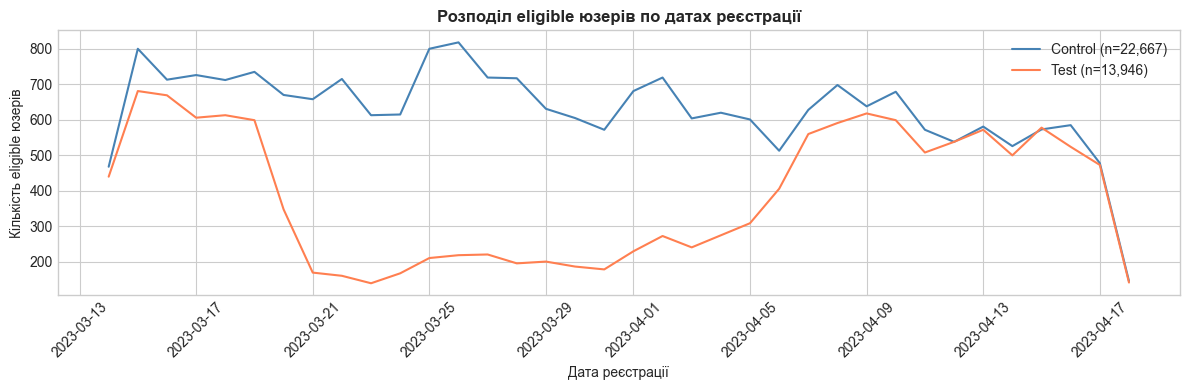

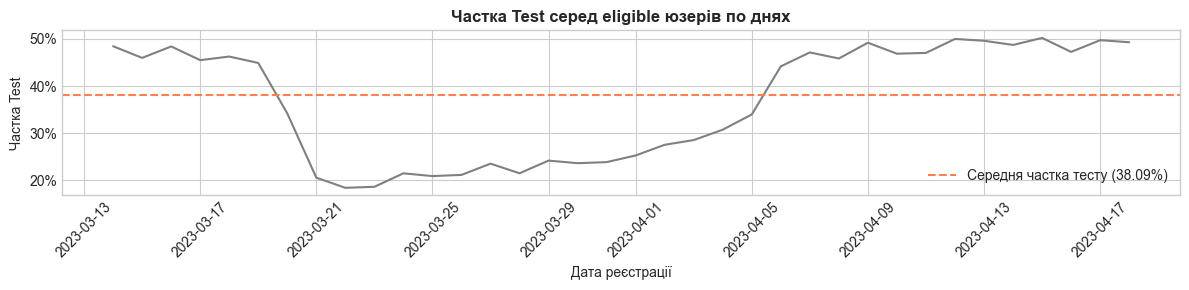

In [94]:
ctrl_clean['reg_date'] = ctrl_clean['date_reg'].dt.date
test_clean['reg_date'] = test_clean['date_reg'].dt.date

daily_ctrl = ctrl_clean.groupby('reg_date').size()
daily_test = test_clean.groupby('reg_date').size()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_ctrl.index, daily_ctrl.values,
        color='steelblue', linewidth=1.5, label=f'Control (n={n_ctrl:,})')
ax.plot(daily_test.index, daily_test.values,
        color='coral', linewidth=1.5, label=f'Test (n={n_test:,})')
ax.set_xlabel('Дата реєстрації')
ax.set_ylabel('Кількість eligible юзерів')
ax.set_title('Розподіл eligible юзерів по датах реєстрації', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

# Частка тесту від загального по днях
ratio = (daily_test / (daily_ctrl + daily_test)).fillna(0)

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(ratio.index, ratio.values, color='gray', linewidth=1.5)
ax.axhline(n_test / n_total, color='coral', linestyle='--',
           linewidth=1.5, label=f'Середня частка тесту ({n_test/n_total:.2%})')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_xlabel('Дата реєстрації')
ax.set_ylabel('Частка Test')
ax.set_title('Частка Test серед eligible юзерів по днях', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

### 8.3 CR по тижнях реєстрації

Перевіряємо чи стабільний ефект нагадування протягом всього тесту. Враховуючи що баг був сконцентрований в період 20-31 березня — важливо переконатись що результат не тягнеться з якогось конкретного тижня, а є стабільним.

Для порівняння розподілів використовуємо **Mann-Whitney U тест** — він не вимагає нормальності розподілу (CR по тижнях може бути нерівномірним) і коректно працює з малими вибірками по тижнях.

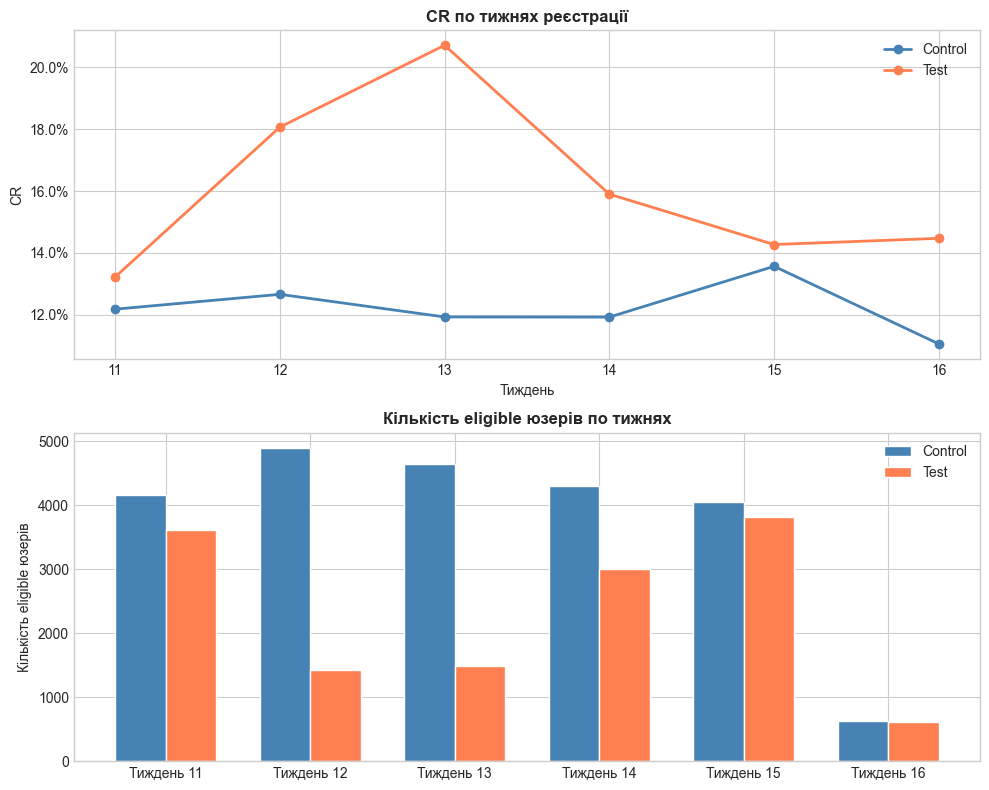

                     CR ПО ТИЖНЯХ                      
   Тиждень   Control CR      Test CR  n Control     n Test
-------------------------------------------------------
        11       12.18%       13.22%      4,154      3,608
        12       12.66%       18.07%      4,889      1,417
        13       11.93%       20.71%      4,644      1,487
        14       11.92%       15.90%      4,302      3,000
        15       13.57%       14.27%      4,054      3,819
        16       11.06%       14.47%        624        615

Mann-Whitney p-value: 0.0043
✅ CR тесту стабільно вищий за контроль протягом всього тесту


In [109]:
ctrl_clean['week'] = ctrl_clean['date_reg'].dt.isocalendar().week.astype(int)
test_clean['week'] = test_clean['date_reg'].dt.isocalendar().week.astype(int)
cr_ctrl_week = ctrl_clean.groupby('week')['date_first_payment'].apply(
    lambda x: x.notna().mean()
)
cr_test_week = test_clean.groupby('week')['date_first_payment'].apply(
    lambda x: x.notna().mean()
)
n_ctrl_week = ctrl_clean.groupby('week').size()
n_test_week = test_clean.groupby('week').size()
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
# CR по тижнях
ax = axes[0]
ax.plot(cr_ctrl_week.index, cr_ctrl_week.values,
        color='steelblue', linewidth=2, marker='o', label='Control')
ax.plot(cr_test_week.index, cr_test_week.values,
        color='coral', linewidth=2, marker='o', label='Test')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
ax.set_xlabel('Тиждень')
ax.set_ylabel('CR')
ax.set_title('CR по тижнях реєстрації', fontweight='bold')
ax.legend()
# Кількість юзерів по тижнях
ax = axes[1]
x = np.arange(len(n_ctrl_week))
width = 0.35
ax.bar(x - width/2, n_ctrl_week.values, width,
       color='steelblue', edgecolor='white', label='Control')
ax.bar(x + width/2, n_test_week.values, width,
       color='coral', edgecolor='white', label='Test')
ax.set_xticks(x)
ax.set_xticklabels([f'Тиждень {w}' for w in n_ctrl_week.index])
ax.set_ylabel('Кількість eligible юзерів')
ax.set_title('Кількість eligible юзерів по тижнях', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
# Mann-Whitney по CR тижнів
_, p_mw_weeks = mannwhitneyu(
    cr_ctrl_week.values,
    cr_test_week.values,
    alternative='two-sided'
)
print("=" * 55)
print(f"{'CR ПО ТИЖНЯХ':^55}")
print("=" * 55)
print(f"{'Тиждень':>10} {'Control CR':>12} {'Test CR':>12} {'n Control':>10} {'n Test':>10}")
print("-" * 55)
for week in cr_ctrl_week.index:
    print(f"{week:>10} {cr_ctrl_week[week]:>12.2%} {cr_test_week[week]:>12.2%} "
          f"{n_ctrl_week[week]:>10,} {n_test_week[week]:>10,}")
print()
print(f"Mann-Whitney p-value: {p_mw_weeks:.4f}")
if p_mw_weeks < 0.05:
    print("✅ CR тесту стабільно вищий за контроль протягом всього тесту")
else:
    print("⚠️  Різниця по тижнях не стабільна")
print("=" * 55)

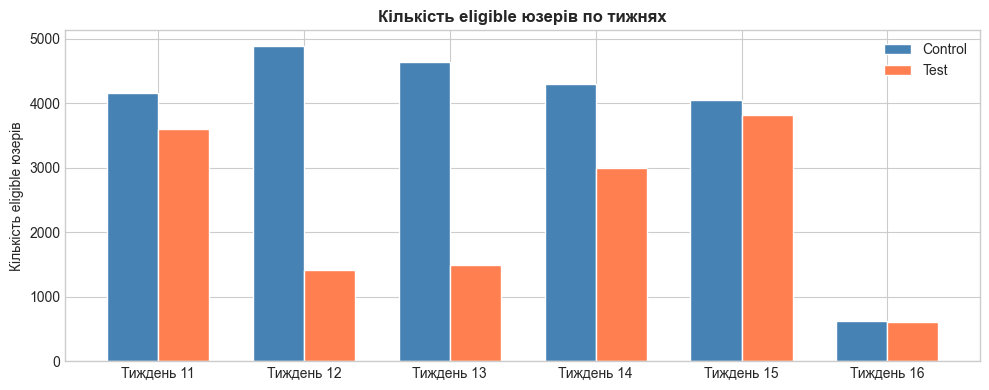

In [112]:
# Блок 3 — графік кількості юзерів по тижнях
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(n_ctrl_week))
width = 0.35
ax.bar(x - width/2, n_ctrl_week.values, width,
       color='steelblue', edgecolor='white', label='Control')
ax.bar(x + width/2, n_test_week.values, width,
       color='coral', edgecolor='white', label='Test')
ax.set_xticks(x)
ax.set_xticklabels([f'Тиждень {w}' for w in n_ctrl_week.index])
ax.set_ylabel('Кількість eligible юзерів')
ax.set_title('Кількість eligible юзерів по тижнях', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Спостереження:** В тижнях 12-13 (20-31 березня) тестова група має суттєво менше юзерів через баг системи — залишились лише ті хто точно отримав нагадування. Це пояснює аномально високий CR в цей період (18-20%). Тиждні 14-16 де баг менше впливав показують більш репрезентативний ефект (~14-16%).

CR тесту вищий за контроль в кожному тижні — ефект стабільний і не тягнеться з одного конкретного періоду.

## 9. Статистичний тест

Маємо дві групи eligible юзерів:
- **Control** — не отримували нагадування
- **Test** — отримали нагадування

Порівнюємо конверсію в першу оплату між групами.

**Використовуємо Chi-squared тест** — стандартний метод для порівняння двох бінарних пропорцій (заплатив / не заплатив). Він не вимагає нормальності розподілу і коректно працює з великими вибірками.

**Гіпотези:**
- H0: різниці в конверсії між групами немає
- H1: конверсія в тестовій групі вища ніж в контрольній

            РЕЗУЛЬТАТИ СТАТИСТИЧНОГО ТЕСТУ             
                               Control         Test
-------------------------------------------------------
Юзерів                          22,667       13,946
Заплатили                        2,811        2,152
CR                              12.40%       15.43%

Абсолютний uplift:              +3.03%
Відносний uplift:              +24.43%
Chi2:                          67.3732
p-value:                        0.0000
95% CI:                   [+2.29%, +3.77%]

✅ H0 відхиляється — результат статистично значущий (p < 0.05)
   CI повністю вище нуля — ефект позитивний


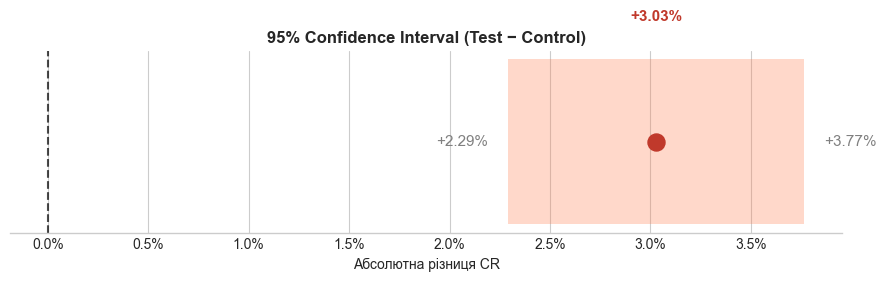

In [96]:
ctrl_cr = ctrl_clean['date_first_payment'].notna().mean()
test_cr = test_clean['date_first_payment'].notna().mean()

paid_ctrl = ctrl_clean['date_first_payment'].notna().sum()
paid_test = test_clean['date_first_payment'].notna().sum()

table = [[paid_ctrl, n_ctrl - paid_ctrl],
         [paid_test, n_test - paid_test]]

chi2, p_value, dof, _ = chi2_contingency(table)

diff  = test_cr - ctrl_cr
se    = np.sqrt(ctrl_cr*(1-ctrl_cr)/n_ctrl + test_cr*(1-test_cr)/n_test)
ci_lo = diff - 1.96*se
ci_hi = diff + 1.96*se

print("=" * 55)
print(f"{'РЕЗУЛЬТАТИ СТАТИСТИЧНОГО ТЕСТУ':^55}")
print("=" * 55)
print(f"{'':25} {'Control':>12} {'Test':>12}")
print("-" * 55)
print(f"{'Юзерів':25} {n_ctrl:>12,} {n_test:>12,}")
print(f"{'Заплатили':25} {paid_ctrl:>12,} {paid_test:>12,}")
print(f"{'CR':25} {ctrl_cr:>12.2%} {test_cr:>12.2%}")
print()
print(f"{'Абсолютний uplift:':25} {diff:>+12.2%}")
print(f"{'Відносний uplift:':25} {diff/ctrl_cr:>+12.2%}")
print(f"{'Chi2:':25} {chi2:>12.4f}")
print(f"{'p-value:':25} {p_value:>12.4f}")
print(f"{'95% CI:':25} [{ci_lo:+.2%}, {ci_hi:+.2%}]")
print()
if p_value < 0.05:
    print("✅ H0 відхиляється — результат статистично значущий (p < 0.05)")
    print("   CI повністю вище нуля — ефект позитивний")
else:
    print("❌ H0 не відхиляється — результат НЕ значущий (p > 0.05)")
print("=" * 55)

# Візуалізація CI
fig, ax = plt.subplots(figsize=(9, 3))
ax.barh([''], [ci_hi - ci_lo], left=ci_lo,
        color='coral', alpha=0.3, height=0.3)
ax.scatter([diff], [''], color='#c0392b', s=150, zorder=5)
ax.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(ci_lo - 0.001, 0, f'{ci_lo:+.2%}',
        ha='right', va='center', fontsize=11, color='gray')
ax.text(ci_hi + 0.001, 0, f'{ci_hi:+.2%}',
        ha='left', va='center', fontsize=11, color='gray')
ax.text(diff, 0.22, f'{diff:+.2%}',
        ha='center', fontsize=11, fontweight='bold', color='#c0392b')
ax.set_yticks([])
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
ax.set_xlabel('Абсолютна різниця CR')
ax.set_title('95% Confidence Interval (Test − Control)', fontweight='bold')
ax.spines[['top', 'right', 'left']].set_visible(False)
plt.tight_layout()
plt.show()

## 10. Додатковий аналіз: час до першої оплати

Перевіряємо чи нагадування не лише збільшує кількість платників але й прискорює момент оплати. Рахуємо час від реєстрації до першої оплати серед тих хто заплатив.

Використовуємо **Mann-Whitney U тест** — розподіл часу до оплати зазвичай скошений вправо (більшість платить швидко, хвіст довгий), тому t-тест некоректний.

In [113]:
# Блок 1 — розрахунок часу до оплати
ctrl_payers = ctrl_clean[ctrl_clean['date_first_payment'].notna()].copy()
test_payers = test_clean[test_clean['date_first_payment'].notna()].copy()

ctrl_payers['hours_to_pay'] = (
    ctrl_payers['date_first_payment'] - ctrl_payers['date_reg']
).dt.total_seconds() / 3600

test_payers['hours_to_pay'] = (
    test_payers['date_first_payment'] - test_payers['date_reg']
).dt.total_seconds() / 3600

print("=" * 55)
print(f"{'ЧАС ДО ПЕРШОЇ ОПЛАТИ (год)':^55}")
print("=" * 55)
print(f"{'':20} {'Control':>15} {'Test':>15}")
print("-" * 55)
print(f"{'Кількість':20} {len(ctrl_payers):>15,} {len(test_payers):>15,}")
print(f"{'Медіана':20} {ctrl_payers['hours_to_pay'].median():>15.1f} {test_payers['hours_to_pay'].median():>15.1f}")
print(f"{'Середня':20} {ctrl_payers['hours_to_pay'].mean():>15.1f} {test_payers['hours_to_pay'].mean():>15.1f}")
print(f"{'25 перцентиль':20} {ctrl_payers['hours_to_pay'].quantile(0.25):>15.1f} {test_payers['hours_to_pay'].quantile(0.25):>15.1f}")
print(f"{'75 перцентиль':20} {ctrl_payers['hours_to_pay'].quantile(0.75):>15.1f} {test_payers['hours_to_pay'].quantile(0.75):>15.1f}")
print()

_, p_mw = mannwhitneyu(
    ctrl_payers['hours_to_pay'],
    test_payers['hours_to_pay'],
    alternative='two-sided'
)
print(f"Mann-Whitney p-value: {p_mw:.4f}")
if p_mw < 0.05:
    print("✅ Різниця в часі статистично значуща")
else:
    print("❌ Різниця в часі НЕ значуща — нагадування не прискорює оплату")
print("=" * 55)

              ЧАС ДО ПЕРШОЇ ОПЛАТИ (год)               
                             Control            Test
-------------------------------------------------------
Кількість                      2,811           2,152
Медіана                         10.4            17.9
Середня                        212.3           242.0
25 перцентиль                    0.9             1.0
75 перцентиль                   91.2           139.6

Mann-Whitney p-value: 0.0004
✅ Різниця в часі статистично значуща


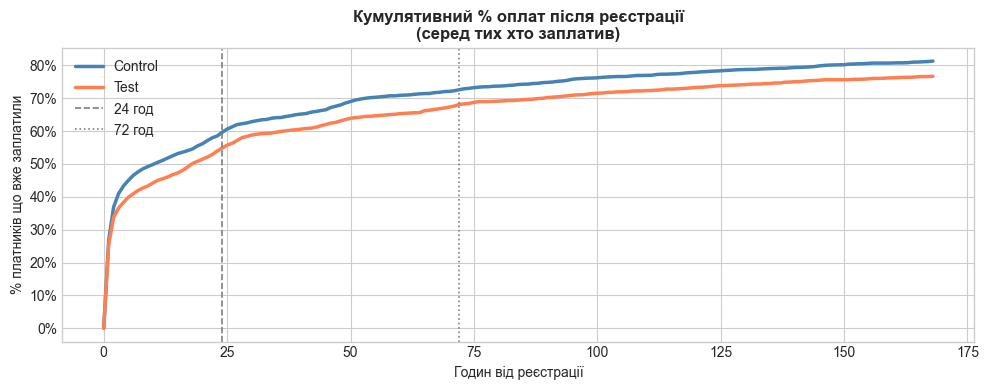

In [114]:
# Блок 2 — кумулятивний графік
cap   = 168
hours = range(0, cap + 1)

ctrl_cum = [(ctrl_payers['hours_to_pay'] <= h).mean() for h in hours]
test_cum = [(test_payers['hours_to_pay'] <= h).mean() for h in hours]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hours, ctrl_cum, color='steelblue', linewidth=2.5, label='Control')
ax.plot(hours, test_cum, color='coral',     linewidth=2.5, label='Test')
ax.axvline(24, color='gray', linestyle='--', linewidth=1.2, label='24 год')
ax.axvline(72, color='gray', linestyle=':',  linewidth=1.2, label='72 год')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_xlabel('Годин від реєстрації')
ax.set_ylabel('% платників що вже заплатили')
ax.set_title('Кумулятивний % оплат після реєстрації\n(серед тих хто заплатив)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [115]:
# Блок 3 — % що заплатили в перші N годин
print(f"{'':10} {'Control':>10} {'Test':>10}")
print("-" * 32)
for h in [1, 6, 24, 48, 72, 168]:
    c = (ctrl_payers['hours_to_pay'] <= h).mean()
    t = (test_payers['hours_to_pay'] <= h).mean()
    print(f"до {str(h)+'год':>6}  {c:>10.1%} {t:>10.1%}")

              Control       Test
--------------------------------
до   1год       26.8%      25.4%
до   6год       46.5%      40.9%
до  24год       59.6%      54.8%
до  48год       67.9%      63.1%
до  72год       72.6%      68.1%
до 168год       81.3%      76.7%


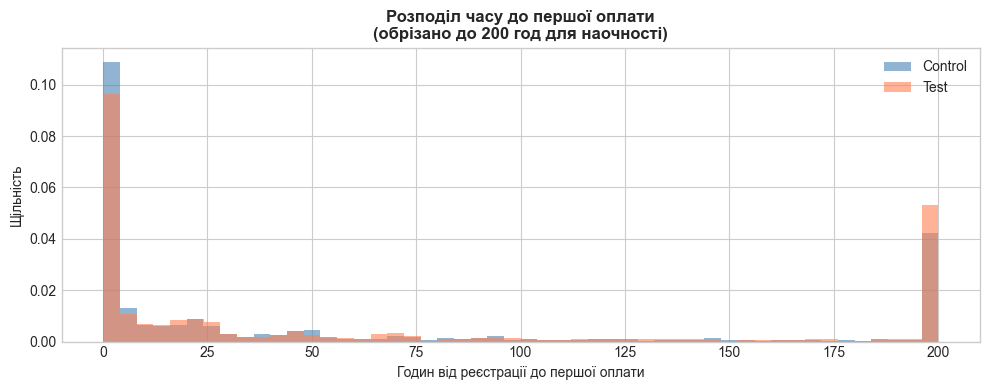

In [117]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ctrl_payers['hours_to_pay'].clip(upper=200), bins=50,
        color='steelblue', alpha=0.6, label='Control', density=True)
ax.hist(test_payers['hours_to_pay'].clip(upper=200), bins=50,
        color='coral', alpha=0.6, label='Test', density=True)
ax.set_xlabel('Годин від реєстрації до першої оплати')
ax.set_ylabel('Щільність')
ax.set_title('Розподіл часу до першої оплати\n(обрізано до 200 год для наочності)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
